# Feedforward FxLMS with acoustic feedback — Karl and Sachau (2024)

Simulates a feedforward controller with a reference microphone, actuator-to-reference acoustic feedback, and an error microphone. Renders no-ANC and controlled stimuli for comparison; the room currently uses direct sound only.

Source: Karl and Sachau (2024), [“Comparison of feedback and feedforward active noise control concepts in an application with a partially open window”](https://past.isma-isaac.be/downloads/isma2024/proceedings/Contribution_554_proceeding_3.pdf).

**Step-size limitation.** The step size calculated with the method described by Karl and Sachau was too small for useful convergence in these simulations. Its value was scaled experimentally for each stimulus. Automatically selecting an appropriate step size remains an open implementation task.

Run the cells in order after installing the project from the repository root (see the [README](../../README.md)).

In [16]:
from pathlib import Path
from helpers.paths import WAVS_DIR

import numpy as np
import matplotlib.pyplot as plt
import pyroomacoustics as pra
from scipy.fft import next_fast_len
from scipy.io import wavfile
from scipy.signal import butter, resample_poly, sosfilt

from helpers.adaptMultichannel import adaptMultichannel
from helpers.truncatePathsModels import truncatePathsModels


Simulation:

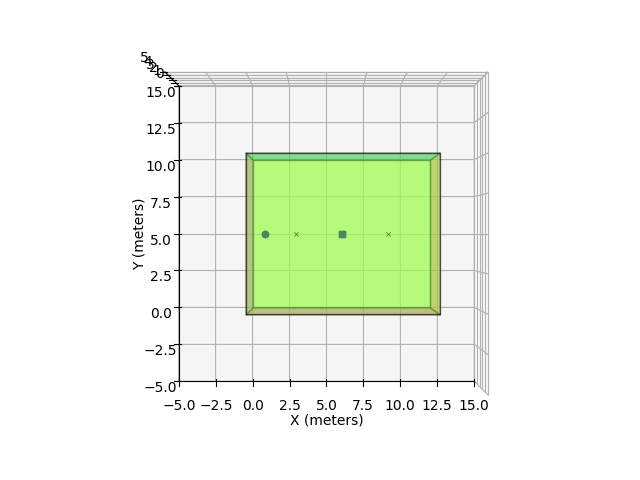

In [ ]:
# Create a room at the final renderer sample rate
fs = 48000
room = pra.ShoeBox([12, 10, 5], fs=fs, max_order=0)

# Noise source
room.add_source([1, 5, 2.5])

# Reference microphones
room.add_microphone([3, 5, 2.5], fs=fs)

# Actuators
room.add_source([6, 5, 2.5])

# Error microphones
room.add_microphone([9, 5, 2.5], fs=fs)

fig, ax = room.plot()
ax.view_init(elev=90, azim=-90)
ax.set_title("Top view of the room")
ax.set_xlim(-5, 15)
ax.set_ylim(-5, 15)
plt.grid(True)
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.show()


Obtain RIRs:

In [18]:
nReferenceMics = 1
nActuators = 1
nErrorMics = 1

room.compute_rir()
referencePaths = [room.rir[m][0] for m in range(nReferenceMics)]
primaryPaths = [room.rir[m][0] for m in range(nReferenceMics, nReferenceMics + nErrorMics)]
secondaryPaths = [[room.rir[m][s] for s in range(1, nActuators + 1)] for m in range(nReferenceMics, nReferenceMics + nErrorMics)]
feedbackPaths = [[room.rir[m][s]for s in range(1, nActuators + 1)]for m in range(nReferenceMics)]

# Shape RIRs for efficient convolution
referencePaths = np.array([
    np.pad(h, (0, max(len(h) for h in referencePaths) - len(h)))
    for h in referencePaths
])

primaryPaths = np.array([
    np.pad(h, (0, max(len(h) for h in primaryPaths) - len(h)))
    for h in primaryPaths
])

maxSecondaryLen  = max(len(h) for row in secondaryPaths for h in row)
secondaryPaths = np.array([
    [np.pad(h, (0, maxSecondaryLen - len(h))) for h in row]
    for row in secondaryPaths
])

maxFeedbackLen = max(len(h)for row in feedbackPaths for h in row)
feedbackPaths = np.array([
    [np.pad(h, (0, maxFeedbackLen - len(h)))for h in row]
    for row in feedbackPaths
])

print("Reference paths shape: ", referencePaths.shape)
print("Primary paths shape: ", primaryPaths.shape)
print("Secondary paths shape: ", secondaryPaths.shape)
print("Feedback paths shape: ", feedbackPaths.shape)

Reference paths shape:  (1, 362)
Primary paths shape:  (1, 1202)
Secondary paths shape:  (1, 1, 502)
Feedback paths shape:  (1, 1, 502)


Algorithm:

Secondary model: 462
Feedback model: 462
Required minimum: 924
nTaps: 1024


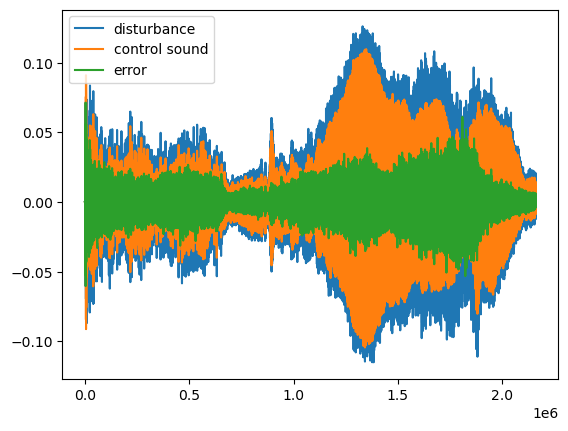

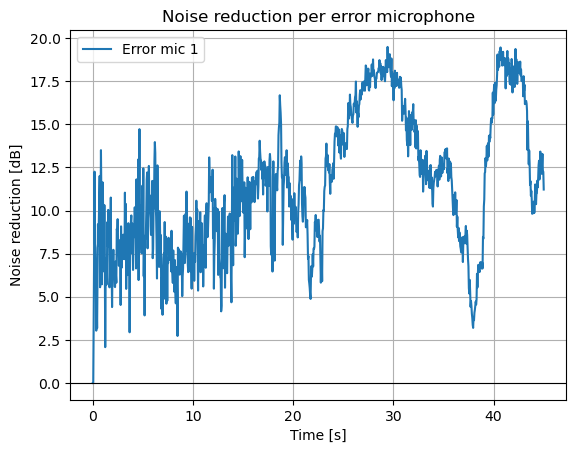

Exported duration: 15.0 s


In [48]:
# Disturbance
blocklength = 2048

stimulusFiles = [
    WAVS_DIR / "stimulus01_continuousTraffic_45s.wav",
    WAVS_DIR / "stimulus02_heavyVehiclePass_45s.wav",
    WAVS_DIR / "stimulus03_pneumaticDrill_45s.wav",
]
stimulusIndex = 1

stimulusFs, x = wavfile.read(stimulusFiles[stimulusIndex])

if stimulusFs != fs:
    raise ValueError(f"Stimulus fs is {stimulusFs} Hz, but simulation fs is {fs} Hz")

if x.ndim > 1:
    x = np.mean(x, axis=1)

if np.issubdtype(x.dtype, np.integer):
    integerInfo = np.iinfo(x.dtype)
    x = x.astype(np.float64) / max(abs(integerInfo.min), integerInfo.max)
else:
    x = x.astype(np.float64)

originalSampleCount = len(x)
nBlocks = int(np.ceil(originalSampleCount / blocklength))
N = nBlocks * blocklength
x = np.pad(x, (0, N - originalSampleCount))
t = np.arange(N) * (1/fs)

# Adaptive filter matrix definition
nTaps = 1024
wFilter = np.zeros((nActuators, nReferenceMics, nTaps)) 

# Truncate IR models
secondaryPathsHat = secondaryPaths.copy()  # Ideal case where G = GHat
feedbackPathsHat = feedbackPaths.copy()    # Ideal case where F = FHat
secondaryPathsHat = truncatePathsModels(secondaryPaths.copy())
feedbackPathsHat = truncatePathsModels(feedbackPaths.copy())

if(secondaryPathsHat.shape[2] + feedbackPathsHat.shape[2] > nTaps):
    print("Warning, L + B > N")

print("Secondary model:", secondaryPathsHat.shape[2])
print("Feedback model:", feedbackPathsHat.shape[2])
print("Required minimum:", secondaryPathsHat.shape[2] + feedbackPathsHat.shape[2])
print("nTaps:", nTaps)

# Running power estimate
referencePower = 0.0
errorPower = 0.0
beta = 1/nTaps
betaBlock = 1 - (1 - beta)**blocklength    # Accumulated beta in a block

# Spectrums and buffers for online convolution
Mr = referencePaths.shape[1]
Nr = blocklength + Mr - 1
rSpectrum = np.fft.rfft(referencePaths, n=Nr, axis=-1)
rBuffer = np.zeros(Mr - 1)

Mp = primaryPaths.shape[1]
Np = blocklength + Mp - 1
pSpectrum = np.fft.rfft(primaryPaths, n=Np, axis=-1)
pBuffer = np.zeros(Mp - 1)

Mw = nTaps
wBuffer = np.zeros((nReferenceMics, Mw - 1))

Mg = secondaryPaths.shape[2]
Ng = blocklength + Mg - 1
gSpectrum = np.fft.rfft(secondaryPaths, n=Ng, axis=-1)
gBuffer = np.zeros((nActuators, Mg - 1))

MgHat = secondaryPathsHat.shape[2]
NgHat = blocklength + MgHat - 1
gHatSpectrum = np.fft.rfft(secondaryPathsHat, n=NgHat, axis=-1)
gHatBuffer = np.zeros((nReferenceMics, MgHat - 1))

Mf = feedbackPaths.shape[2]
fBuffer = np.zeros((nActuators, Mf - 1))

MfHat = feedbackPathsHat.shape[2]
fHatBuffer = np.zeros((nActuators, MfHat - 1))

# Maximum secondary path delay
threshold = 0.1 * np.max(np.abs(secondaryPathsHat),axis=-1,keepdims=True)
secondaryDelays = np.argmax(np.abs(secondaryPathsHat) >= threshold,axis=-1)
maxSecondaryDelay = np.max(secondaryDelays)

# For testing
xRef = np.zeros((nReferenceMics, N))
d = np.zeros((nErrorMics, N))
u = np.zeros((nActuators, N))
y = np.zeros((nErrorMics, N))
e = np.zeros((nErrorMics, N))

for k in range(nBlocks):
    # Block samples of X (simulation)
    xSignal = x[k*blocklength : (k+1)*blocklength]
    
    ################## Physical signals ##################

    # Reference signals (simulation) -> only the noise signals picked up by the actuator
    xSignalExt = np.concatenate([rBuffer, xSignal])
    xSpectrum = np.fft.rfft(xSignalExt, n=Nr)
    rSignalsSpectrum = rSpectrum * xSpectrum
    rSignalsExt = np.fft.irfft(rSignalsSpectrum, n=Nr, axis=-1)
    rSignals = rSignalsExt[:, Mr - 1:]
    rBuffer = xSignalExt[-(Mr - 1):]
        
    # Disturbance signals (simulation)
    xSignalExt = np.concatenate([pBuffer, xSignal])
    xSpectrum = np.fft.rfft(xSignalExt, n=Np)
    dSignalsSpectrum = pSpectrum * xSpectrum
    dSignalsExt = np.fft.irfft(dSignalsSpectrum, n=Np, axis=-1)
    dSignals = dSignalsExt[:, Mp - 1:]
    pBuffer = xSignalExt[-(Mp - 1):]

    # Reference and actuator signals (simulation)
    # This convolution has to be made sample by sample due to the feedback loop
    physicalFeedbackSignals = np.zeros((nReferenceMics, blocklength))
    compensatedReferenceSignals = np.zeros((nReferenceMics, blocklength))
    aSignals = np.zeros((nActuators, blocklength))
    
    for n in range(blocklength):
        # Reference sample
        physicalFeedbackSample = np.einsum(
            'kmt,mt->k',
            feedbackPaths[:, :, 1:],
            fBuffer[:, ::-1]
        )

        # Reference sample from noise source + from feedback path
        measuredReferenceSample = rSignals[:, n] + physicalFeedbackSample

        # Artificial sample
        artificialFeedbackSample = np.einsum(
            'kmt,mt->k',
            feedbackPathsHat[:, :, 1:],
            fHatBuffer[:, ::-1]
        )

        # Meassured reference sample - sample from artificial feedback path
        compensatedReferenceSample = measuredReferenceSample - artificialFeedbackSample

        # Actuator Sample
        actuatorsSample = (
            wFilter[:, :, 0]
            @ compensatedReferenceSample
        )
        actuatorsSample += np.einsum(
            'mkt,kt->m',
            wFilter[:, :, 1:],
            wBuffer[:, ::-1]
        )

        # Save samples into signal blocks
        physicalFeedbackSignals[:, n] = physicalFeedbackSample
        compensatedReferenceSignals[:, n] = compensatedReferenceSample
        aSignals[:, n] = actuatorsSample

        # Update buffers
        wBuffer[:, :-1] = wBuffer[:, 1:]
        wBuffer[:, -1] = compensatedReferenceSample
        fBuffer[:, :-1] = fBuffer[:, 1:]
        fBuffer[:, -1] = actuatorsSample
        fHatBuffer[:, :-1] = fHatBuffer[:, 1:]
        fHatBuffer[:, -1] = actuatorsSample
    
    # Control and Errors signals (simulation)
    aSignalsExt = np.concatenate([gBuffer, aSignals], axis=1)
    aSignalsSpectrum = np.fft.rfft(aSignalsExt, n=Ng, axis=-1)
    cSignalsSpectrum = np.einsum('emf,mf->ef', gSpectrum, aSignalsSpectrum)
    cSignalsExt = np.fft.irfft(cSignalsSpectrum, n=Ng, axis=-1)
    cSignals = cSignalsExt[:, Mg - 1:]
    gBuffer = aSignalsExt[:, -(Mg - 1):]
       
    eSignals = dSignals - cSignals
    
    ################## Algorithm ##################

    # Compute the filtered reference matrix
    rSignalsExt = np.concatenate([gHatBuffer, compensatedReferenceSignals], axis=1)   
    rSignalsSpectrum = np.fft.rfft(rSignalsExt, n=NgHat, axis=-1)   
    frSignalsSpectrum = np.einsum('emf,kf->emkf', gHatSpectrum, rSignalsSpectrum)   # Extra time could be saved here, since this fft is calculated inside adaptMultichannel
    frSignalsExt = np.fft.irfft(frSignalsSpectrum, n=NgHat, axis=-1)
    frSignals = frSignalsExt[..., MgHat - 1:]
    gHatBuffer = rSignalsExt[:, -(MgHat - 1):]

    # Calculate the running power estimate
    referencePowerBlock = np.mean(frSignals**2)
    errorPowerBlock = np.mean(eSignals**2)
    referencePower = (1 - betaBlock) * referencePower + betaBlock * referencePowerBlock
    errorPower = (1 - betaBlock) * errorPower + betaBlock * errorPowerBlock

    # Calculate the VSS
    muVss = (2 * errorPower) / (nTaps* referencePower + 1e-12)
    maxMu = 1 / (referencePower * (nTaps + 2 + 2 * maxSecondaryDelay))
    mu = min(muVss, maxMu) * 2500  # 2000, , 7000
    
    # Calculate the leakage factor
    leakageBlock = (1 - mu / nTaps**2)

    # LMS algorithm
    wFilter = adaptMultichannel(
        frSignals,
        eSignals,
        nTaps,
        blocklength,
        wFilter,
        mu,
        #leakageBlock
    )
    
    ################## For testing ##################
    start = k * blocklength
    end = (k + 1) * blocklength

    xRef[:, start:end] = compensatedReferenceSignals
    d[:, start:end] = dSignals
    u[:, start:end] = aSignals
    y[:, start:end] = cSignals
    e[:, start:end] = eSignals

plt.plot(d[0], label="disturbance")
plt.plot(y[0], label="control sound")
plt.plot(e[0], label="error")
plt.legend()
plt.show()

dBlocks = d.reshape(nErrorMics, nBlocks, blocklength)
eBlocks = e.reshape(nErrorMics, nBlocks, blocklength)

dPower = np.mean(dBlocks**2, axis=-1)
ePower = np.mean(eBlocks**2, axis=-1)

noiseReductionDb = 10 * np.log10(
    (dPower + 1e-12) / (ePower + 1e-12)
)

blockTime = (np.arange(nBlocks) + 0.5) * blocklength / fs

plt.figure()

for nError in range(nErrorMics):
    plt.plot(
        blockTime,
        noiseReductionDb[nError],
        label=f'Error mic {nError + 1}'
    )

plt.axhline(0, color='black', linewidth=0.8)
plt.title('Noise reduction per error microphone')
plt.xlabel('Time [s]')
plt.ylabel('Noise reduction [dB]')
plt.grid()
plt.legend()
plt.show()

# Export assessed interval: 30–45 s
errorMicIndex = 0
preRollSamples = int(30 * fs)

dToExport = d[
    errorMicIndex,
    preRollSamples:originalSampleCount
]

eToExport = e[
    errorMicIndex,
    preRollSamples:originalSampleCount
]

stimulusName = Path(stimulusFiles[stimulusIndex]).stem

wavfile.write(
    str(WAVS_DIR / f"{stimulusName}_noANC.wav"),
    fs,
    dToExport.astype(np.float32)
)

wavfile.write(
    str(WAVS_DIR / f"{stimulusName}_FFW.wav"),
    fs,
    eToExport.astype(np.float32)
)

print("Exported duration:", len(eToExport) / fs, "s")
